In [1]:
# Colab setup -- installs SoftMobility when running on Google Colab.
# Safe to run locally: it does nothing outside Colab.
try:
    import google.colab  # noqa: F401
    %pip install -q git+https://github.com/C0PEP0D/SoftMobility.git
except ImportError:
    pass

# Draft 17. Soft dumbbell in shear flow — attractor selection by a single stretch DOF

## Background

Example 05 reproduced Jeffery's tumbling orbit for the *rigid* symmetric
two-bead dumbbell (radii $a=1$, centres at $\pm 1.5\,\hat{\mathbf{e}}_1$).
For a rigid axisymmetric body in simple shear, the orbit constant
$K\;=\;\tan\theta\,\sqrt{\cos^{2}\!\varphi+c^{2}\sin^{2}\!\varphi}$
($c=\sqrt{(1+B)/(1-B)}$) is conserved exactly, so every orbit is
closed and neutrally stable.

Adding a single internal degree of freedom — a linear Hookean spring
along the body axis — couples the orientation to a dissipative
internal mode and lifts the degeneracy. Two attractors compete:

* **Tumbling** in the shear plane $\mathbf{e}_1$–$\mathbf{e}_2$
  ($|p_z|\to 0$).
* **Log-rolling** along the vorticity axis $\mathbf{e}_3$
  ($|p_z|\to 1$).

Below we run two 100-period trajectories at $dt = 0.01$:

* **rigid** — no DOF, closed Jeffery orbit at $\theta_0 = 0.8$ (reference);
* **soft** — $k = 100$, $\theta_0 = 0.5$. The stiffness is chosen so
  that $|s|$ stays below the bead gap (0.5) throughout; the DOF still
  lifts the orbit-constant degeneracy and the trajectory drifts onto
  the shear-plane attractor.

The first figure overlays $\theta(t)$ and $s(t)$; the second draws the
three S² trajectories in the same style as `fig_jeffery_s2_orbits` of
example 05.

## Imports

In [ ]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import softmobility as sm
from softmobility.classes import figstyle
from softmobility.classes.figstyle import CAMERA_EYE, SIZES, _eye_to_view

jax.config.update("jax_enable_x64", True)
figstyle.apply()
np.set_printoptions(precision=3, linewidth=100, suppress=True, sign=" ")

FIGDIR = "figures"

## 1. Soft dumbbell with one stretch DOF

Two equal-radius beads ($a=1$) sit at body-frame positions
$\pm(\tfrac{3}{2}+\tfrac{s}{2})\,\hat{\mathbf{e}}_1$, so the rest
length is $L_0 = 3$ and $s$ is the deviation from rest. A linear
Hookean spring of stiffness $k$ contributes a restoring force
$\pm k\,s\,\hat{\mathbf{e}}_1$ on each bead (potential
$U = \tfrac{1}{2} k s^{2}$; virtual-work check
$\sum_i \mathbf{F}_i\!\cdot\!\partial \mathbf{q}_i/\partial s = -k\,s$).
At $k = 100$ the stretch stays bounded well below the rest gap of
$0.5$, so we use the default fast `allow_overlap=False` GRPY branch.

In [3]:
yaml_data = """
dof_names:    [s]
design_names: [stiffness]

defaults:
  s: 0.0
  stiffness: 1.0

spheres:
  - radius: 1
    position: [-(1.5 + s/2), 0, 0]
    force:    [stiffness * s, 0, 0]
  - radius: 1
    position: [ (1.5 + s/2), 0, 0]
    force:    [-stiffness * s, 0, 0]
"""

mybody = sm.SoftBody(yaml_data, verbose=False, allow_overlap=False)
print(repr(mybody))

SPHERE ASSEMBLY
  2 spheres
  1 degrees of freedom
  1 design parameters
  0 input parameters

Default values
  degrees of freedom dof: ['s'] = [ 0.]
  design parameters param: ['stiffness'] = [ 1.]
  input parameters param: []

SPHERE 0
  radius: 1.0
  position: [-1.5  0.   0. ]
  orientation: [ 0.  0.  0.]
  C_H:
[]
  C_K:
[[ 1.]
 [ 0.]
 [ 0.]
 [ 0.]
 [ 0.]
 [ 0.]]

SPHERE 1
  radius: 1.0
  position: [ 1.5  0.   0. ]
  orientation: [ 0.  0.  0.]
  C_H:
[]
  C_K:
[[-1.]
 [ 0.]
 [ 0.]
 [ 0.]
 [ 0.]
 [ 0.]]



## 3. Shear flow and rigid Bretherton parameter

Simple shear $\mathbf{u}=\dot\gamma\,y\,\hat{\mathbf{e}}_1$ with
$\dot\gamma=1$. Bretherton parameter read from the rigid (no-DOF)
twin: $B \approx 0.717$, so $c \approx 2.46$ and Jeffery period
$T = 2\pi(c+1/c)/\dot\gamma \approx 18.02$.

In [4]:
SHEAR_RATE = 1.0
shear_flow = sm.shear_flow(shear_rate=SHEAR_RATE)

rigid_yaml = """
spheres:
  - radius: 1
    position: [-1.5, 0, 0]
  - radius: 1
    position: [ 1.5, 0, 0]
"""
rigid_body = sm.SoftBody(rigid_yaml, verbose=False)

tensors = rigid_body.compute_rigid_tensors()
B = float(tensors.C_E[-1, 1])
c_factor = np.sqrt((1.0 + B) / (1.0 - B))
T_jeffery = 2.0 * np.pi * (c_factor + 1.0 / c_factor) / SHEAR_RATE
print(f"Bretherton parameter B = {B:.4f}")
print(f"Aspect ratio       c  = sqrt((1+B)/(1-B)) = {c_factor:.4f}")
print(f"Jeffery period     T  = 2π (c + 1/c)/γ̇   = {T_jeffery:.4f}")

Bretherton parameter B = 0.7169
Aspect ratio       c  = sqrt((1+B)/(1-B)) = 2.4625
Jeffery period     T  = 2π (c + 1/c)/γ̇   = 18.0238


## 4. Helpers — spherical angles and analytical Jeffery

Copied verbatim from example 05. `p_from_ori(rod_vec)` extracts the
lab-frame direction of the natural axis $\mathbf{E}_1$ from a Rodrigues
vector.

In [5]:
def phi_theta_of_p(p):
    """Spherical angles (φ, θ) of a unit vector p with θ measured from e3."""
    p = np.asarray(p)
    phi = np.arctan2(p[..., 1], p[..., 0])
    theta = np.arccos(p[..., 2])
    return phi, theta


def jeffery_phi_theta(B, phi0, theta0, t, shear_rate=1.0):
    """Closed-form Jeffery orbit for the long-axis spherical angles."""
    c = np.sqrt((1.0 + B) / (1.0 - B))
    tau0 = np.arctan2(-c * np.sin(phi0), np.cos(phi0))
    tau = shear_rate * np.asarray(t) / (c + 1.0 / c) + tau0
    phi = np.arctan2(-np.sin(tau) / c, np.cos(tau))
    K = np.tan(theta0) * np.sqrt(np.cos(phi0) ** 2 + c ** 2 * np.sin(phi0) ** 2)
    theta = np.arctan2(K, np.sqrt(np.cos(phi) ** 2 + c ** 2 * np.sin(phi) ** 2))
    return phi, theta


@jax.jit
def p_from_ori(ori):
    return sm.rotation_matrix(ori) @ jnp.array([1.0, 0.0, 0.0])

## 5. Two 100-period trajectories at $dt = 0.01$

The Rodrigues vector $(0,\,-(\pi/2-\theta_0),\,0)$ rotates the body
axis $\hat{\mathbf{e}}_1$ to $(\sin\theta_0, 0, \cos\theta_0)$, so we
start with $\varphi_0 = 0$ in the $\mathbf{e}_1$–$\mathbf{e}_3$ plane
at polar angle $\theta_0$ from the vorticity axis.

* **rigid** — no DOF, $\theta_0 = 0.8$ (closed Jeffery orbit).
* **soft** — $k = 100$, $\theta_0 = 0.5$ (drifts onto the shear-plane attractor).

In [6]:
DT = 0.01
N_PERIODS = 100
n_steps = int(N_PERIODS * T_jeffery / DT)
t = (np.arange(n_steps) + 1) * DT
print(f"DT = {DT}, N_PERIODS = {N_PERIODS}, n_steps = {n_steps}")

STIFFNESS = 100.0


def init_ori_for(theta0):
    return jnp.array([0.0, -(np.pi / 2 - theta0), 0.0])


rigid_rollout = sm.FlowBodyRollout(soft_body=rigid_body, flow=shear_flow)
soft_rollout = sm.FlowBodyRollout(soft_body=mybody, flow=shear_flow)

cases = [
    ("rigid", rigid_rollout, None,                     0.5),
    ("soft",  soft_rollout,  jnp.asarray([STIFFNESS]), 0.5),
]

results = {}
for name, rl, design, theta0 in cases:
    init_ori = init_ori_for(theta0)
    if design is None:
        _, oris, dofs = rl.rollout(dt=DT, n_steps=n_steps, init_orientation=init_ori)
    else:
        _, oris, dofs = rl.rollout(dt=DT, n_steps=n_steps, init_orientation=init_ori, design=design)
    p_lab = np.array(jax.vmap(p_from_ori)(oris))
    s_lab = np.array(dofs)
    if s_lab.ndim == 2 and s_lab.shape[1] == 0:
        s_lab = np.zeros((p_lab.shape[0], 1))
    _, theta_lab = phi_theta_of_p(p_lab)
    results[name] = {"theta0": theta0, "p": p_lab, "theta": theta_lab, "s": s_lab[:, 0]}
    print(f"  {name:10s}  θ_0={theta0:.2f}   max|s|={np.max(np.abs(s_lab)):.3e}   "
          f"tail mean|p·e3|={np.mean(np.abs(p_lab[-int(5*T_jeffery/DT):, 2])):.4f}")

DT = 0.01, N_PERIODS = 100, n_steps = 180237
  rigid       θ_0=0.50   max|s|=0.000e+00   tail mean|p·e3|=0.9250
  soft        θ_0=0.50   max|s|=2.645e-01   tail mean|p·e3|=0.0001


## 6. Figure 1 — $\theta(t)$ and $s(t)$ side by side

Left panel: polar angle $\theta(t)$ of the natural body axis from the
vorticity axis. Right panel: stretch $s(t)$ (rigid case is identically
zero, plotted for reference).

The two soft cases bracket the attractor landscape:

* $\theta_0=0.8$ — $\theta$ drifts upward toward $\pi/2$ (shear plane).
* $\theta_0=0.2$ — $\theta$ drifts downward toward $0$ (vorticity axis).

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


PosixPath('figures/fig_soft_theta_s.pdf')

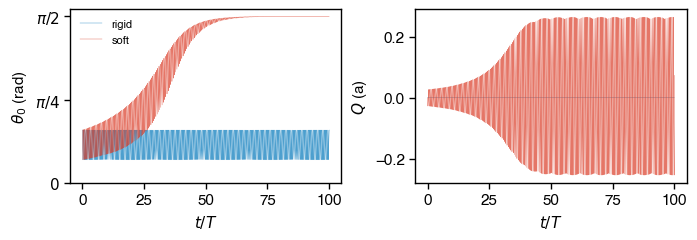

In [7]:
case_style = {
    "rigid": {"color": figstyle.COLORS["blue"], "alpha": 1.0,
              "label": f"rigid"},
    "soft":  {"color": figstyle.COLORS["red"],  "alpha": 1.0,
              "label": f"soft"},
}

# Stride for long plots so the PDF stays small.
stride = max(1, n_steps // 4000)
tn = t[::stride] / T_jeffery

fig_ts, axes_ts = figstyle.subplots(size="full", aspect=658 / 220, ncols=2)
for name in ("rigid", "soft"):
    st = case_style[name]
    axes_ts[0].plot(tn, results[name]["theta"][::stride],
                    color=st["color"], alpha=st["alpha"],
                    linewidth=0.25, label=st["label"])
    axes_ts[1].plot(tn, results[name]["s"][::stride],
                    color=st["color"], alpha=st["alpha"], linewidth=0.25)

axes_ts[0].set_xlabel(r"$t / T$")
axes_ts[0].set_ylabel(r"$\theta_0$ (rad)")
axes_ts[0].set_yticks([0, np.pi / 4, np.pi / 2], [r"$0$", r"$\pi/4$", r"$\pi/2$"])
axes_ts[0].legend(loc="best", frameon=False, fontsize=8)

axes_ts[1].set_xlabel(r"$t / T$")
axes_ts[1].set_ylabel(r"$Q$ (a)")

figstyle.save(fig_ts, "fig_soft_theta_s", figdir=FIGDIR)

## 7. Figure 2 — two S² trajectories side by side

Same visual style as `fig_jeffery_s2_orbits` in example 05: translucent
unit sphere, body axes labelled $\mathbf{e}_1, \mathbf{e}_2,
\mathbf{e}_3$. Trajectories are drawn with low alpha so the density of
overlapping loops is visible. The rigid panel overlays the closed-form
Jeffery samples (scatter) as a validation.

PosixPath('figures/fig_soft_s2.pdf')

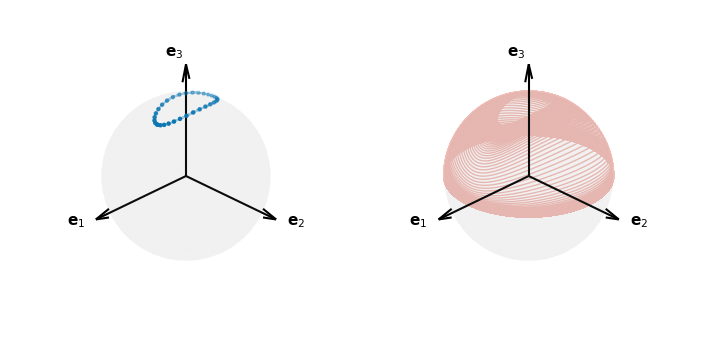

In [8]:

# Build a 3-panel 3D figure that reuses the styling of figstyle.figure_3d
# (orthographic projection, derived camera view, equal box aspect, axes
# hidden, tight margins) so each panel matches example 05's S² plot.
elev, azim = _eye_to_view(CAMERA_EYE)
fig_width = SIZES["full"]
panel_w = fig_width / 2
fig_s2 = plt.figure(figsize=(fig_width, panel_w))

axes_s2 = []
for i in range(2):
    ax = fig_s2.add_subplot(1, 2, i + 1, projection="3d")
    ax.set_proj_type("ortho")
    ax.view_init(elev=elev, azim=azim)
    ax.set_box_aspect((1, 1, 1))
    ax.set_axis_off()
    axes_s2.append(ax)
fig_s2.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0)

u_s, v_s = np.mgrid[0:2 * np.pi:60j, 0:np.pi:30j]

# Analytical Jeffery samples for the rigid panel — first period only,
# strided so they read as well-spaced markers.
rigid_p = results["rigid"]["p"]
phi0_r, theta0_r = phi_theta_of_p(rigid_p[0])
duration_one = int(T_jeffery / DT)
t_one = t[:duration_one]
phi_ana, theta_ana = jeffery_phi_theta(B, phi0_r, theta0_r, t_one, SHEAR_RATE)
p_ana = np.column_stack([
    np.sin(theta_ana) * np.cos(phi_ana),
    np.sin(theta_ana) * np.sin(phi_ana),
    np.cos(theta_ana),
])
ana_stride = max(1, duration_one // 32)

TRAJ_ALPHA = 0.33  # low alpha so dense overlapping loops reveal their density

for ax, name in zip(axes_s2, ("rigid", "soft"), strict=True):
    ax.plot_surface(
        0.998 * np.cos(u_s) * np.sin(v_s),
        0.998 * np.sin(u_s) * np.sin(v_s),
        0.998 * np.cos(v_s),
        color=figstyle.COLORS["grey"], alpha=0.05,
        linewidth=0, antialiased=True, shade=False,
    )
    figstyle.add_body_axes(ax, length=1.5, show_labels=True)
    figstyle.displace_label(ax, "axis_label_E1", text=r"$\mathbf{e}_1$", offset=(0.2, 0, 0))
    figstyle.displace_label(ax, "axis_label_E2", text=r"$\mathbf{e}_2$", offset=(0, 0.2, 0))
    figstyle.displace_label(ax, "axis_label_E3", text=r"$\mathbf{e}_3$", offset=(0.2, 0, 0))

    st = case_style[name]
    p = results[name]["p"]
    ax.plot(p[:, 0], p[:, 1], p[:, 2],
            color=st["color"], alpha=TRAJ_ALPHA, linewidth=1.0,
            label="rollout (RK4)")
    if name == "rigid":
        ax.scatter(p_ana[::ana_stride, 0], p_ana[::ana_stride, 1], p_ana[::ana_stride, 2],
                   color=st["color"], s=5, label="analytical")

    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_zlim(-1.2, 1.2)

figstyle.save(fig_s2, "fig_soft_s2", figdir=FIGDIR)

## Summary

* The rigid dumbbell traces a closed Jeffery orbit; the rollout matches
  the closed-form solution overlaid on the left S² panel.
* Adding one linear stretch DOF at $k = 100$ (with $|s|$ bounded below
  the bead gap of 0.5) lifts the orbit-constant degeneracy: from
  $\theta_0 = 0.5$ the natural axis spirals away from the closed
  Jeffery orbit and onto the $\mathbf{e}_1$–$\mathbf{e}_2$ plane
  (tumbling attractor).